# Solar PV Max Power Point: Unconstrained NLP

The electrical output of a solar PV depends on the voltage at which it is operated.

For a given irradiance and temperature, a PV module has an I–V characteristic, $I = f(V)$. A simple approximation is given by:

$$ I(V) = I_{SC} \left[ 1 - \left( \frac{V}{V_{OC}} \right)^a \right] $$

where $I_{SC}$ is the short-circuit current, $V_{OC}$ is the open-circuit voltage, and $a$ is a shape parameter. 

Since $P=IV$, we need to solve for the $V$ that gives maximum power $P$ given a fixed $a$, $I_{SC}$ and $V_{OC}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ---------------------------------
# Parameters
# ---------------------------------
Isc = 8.0       # Short-circuit current [A]
Voc = 40.0      # Open-circuit voltage [V]
a = 10.0        # Shape parameter

# ---------------------------------
# PV model
# ---------------------------------
def current(V):
    return Isc * (1 - (V / Voc)**a)

def power(V):
    return V * current(V)

# Objective: minimize negative power
def objective(x):
    V = x[0]
    return -power(V)

# ---------------------------------
# Optimization
# ---------------------------------
V0 = 20.0 # initial guess

result = minimize(objective, x0=[V0])

V_opt = result.x[0]
I_opt = current(V_opt)
P_opt = power(V_opt)

print(f"Optimal voltage = {V_opt:.2f} V")
print(f"Current at MPP  = {I_opt:.2f} A")
print(f"Maximum power   = {P_opt:.2f} W")

Optimal voltage = 31.47 V
Current at MPP  = 7.27 A
Maximum power   = 228.89 W


## Plot the solution

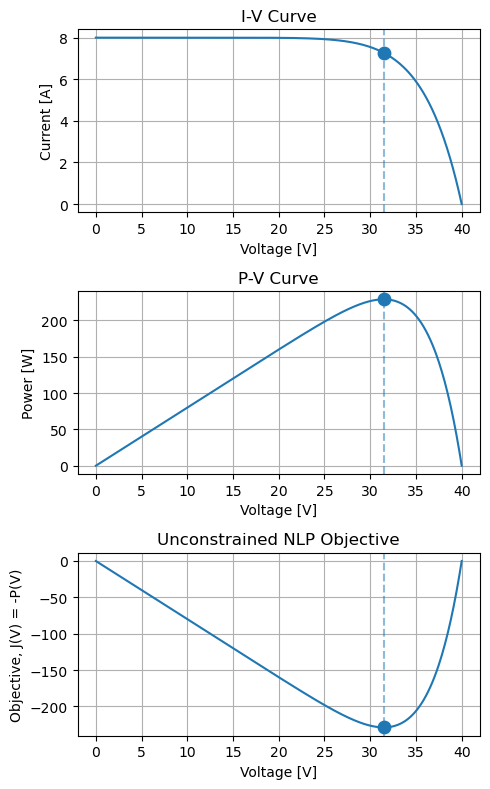

In [2]:
# Voltage range
V = np.linspace(0, Voc, 500)

I = current(V)
P = power(V)
J = -P

fig, ax = plt.subplots(3, 1, figsize=(5, 8))

# ---------------------------------
# I-V curve
# ---------------------------------
ax[0].plot(V, I)
ax[0].scatter(V_opt, I_opt, s=80, zorder=3)
ax[0].axvline(V_opt, linestyle='--', alpha=0.5)

ax[0].set_xlabel("Voltage [V]")
ax[0].set_ylabel("Current [A]")
ax[0].set_title("I-V Curve")
ax[0].grid(True)

# ---------------------------------
# P-V curve
# ---------------------------------
ax[1].plot(V, P)
ax[1].scatter(V_opt, P_opt, s=80, zorder=3)
ax[1].axvline(V_opt, linestyle='--', alpha=0.5)

ax[1].set_xlabel("Voltage [V]")
ax[1].set_ylabel("Power [W]")
ax[1].set_title("P-V Curve")
ax[1].grid(True)

# ---------------------------------
# Objective function
# ---------------------------------
ax[2].plot(V, J)
ax[2].scatter(V_opt, -P_opt, s=80, zorder=3)
ax[2].axvline(V_opt, linestyle='--', alpha=0.5)

ax[2].set_xlabel("Voltage [V]")
ax[2].set_ylabel("Objective, J(V) = -P(V)")
ax[2].set_title("Unconstrained NLP Objective")
ax[2].grid(True)

plt.tight_layout()
plt.show()

## Analytical Solution

Since our NLP is unconstrained, 1-dimensional, and easy to differentiate, we can solve for the optimal $V$ analytically.

$$ P(V) = V \times I_{SC} \left[ 1 - \left( \frac{V}{V_{OC}} \right)^a \right] $$

We obtain the derivative $\frac{dP}{dV}$ as follows:

$$ P(V) = VI_{SC} - \frac{V^{a+1}}{V_{OC}^a}I_{SC} $$

$$ \frac{dP}{dV} = I_{SC} - (a+1)\frac{I_{SC}}{V_{OC}^a} V^a $$

Equating the derivative to zero, we can solve for $V$:

$$ \frac{dP}{dV} = 0 = I_{SC} - (a+1)\frac{I_{SC}}{V_{OC}^a} V^a $$

$$ V_{opt} = \sqrt[a]{\frac{1}{a+1}} V_{OC} $$

Plugging the given values $a=10$ and $V_{OC} = 40V$, we get:

$$ V_{opt} = \sqrt[10]{\frac{1}{11}} 40 = \boxed{31.47 V} $$

In `scipy.optimize`, the default method for unconstrained NLP without variable bounds is BFGS (Broyden-Fletcher-Reeves-Shanno). It does not perform analytical solutions. 